# 📈 Chapter 2: Data and Sampling Distributions
**Referensi Buku:** *Practical Statistics for Data Scientists* (Peter Bruce, Andrew Bruce, Peter Gedeck)

---
> **Topik:** Pengambilan Sampel, Central Limit Theorem, Bootstrap, Confidence Intervals, dan Distribusi Probabilitas
---
## 1. Pendahuluan & Import Library
Di era Big Data, terkadang kita berasumsi bahwa kita tidak lagi membutuhkan sampel karena kita memiliki 'semua data'. Namun kenyataannya, data yang kita miliki seringkali hanyalah 'sampel' dari proses fisik atau kejadian di dunia nyata yang lebih besar. Bab ini fokus pada bagaimana kualitas sampel (dibandingkan kuantitas) sangat menentukan hasil analisis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.utils import resample

%matplotlib inline
np.random.seed(42) # Untuk reproduksibilitas

## 2. Random Sampling dan Sample Bias (Bias Sampel)
Sebuah sampel yang baik adalah sampel yang representatif (mewakili populasi).
- **Simple Random Sampling:** Mengambil data secara acak di mana setiap elemen memiliki peluang yang sama untuk terpilih.
- **Sample Bias:** Terjadi ketika sampel diambil dengan cara yang secara sistematis mengabaikan atau melebih-lebihkan bagian tertentu dari populasi. Kualitas data (*data quality*) lebih penting daripada sekadar jumlah data (*data size*).

Mean Populasi (True Mean) : Rp 56,693.91
Mean Sampel (Estimate)    : Rp 56,403.78


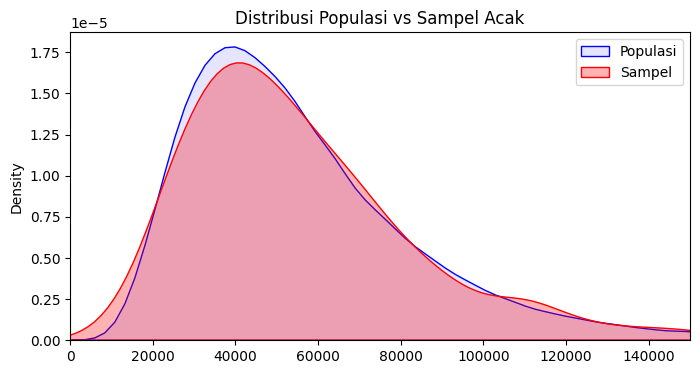

In [2]:
# Simulasi populasi pendapatan (tidak terdistribusi normal, melainkan miring ke kanan / right-skewed)
population = stats.lognorm.rvs(s=0.5, scale=50000, size=100000)

# Mengambil sampel acak sederhana (Simple Random Sample) berukuran 1000
sample = np.random.choice(population, size=1000, replace=False)

print(f"Mean Populasi (True Mean) : Rp {population.mean():,.2f}")
print(f"Mean Sampel (Estimate)    : Rp {sample.mean():,.2f}")

plt.figure(figsize=(8, 4))
sns.kdeplot(population, label='Populasi', color='blue', fill=True, alpha=0.1)
sns.kdeplot(sample, label='Sampel', color='red', fill=True, alpha=0.3)
plt.title("Distribusi Populasi vs Sampel Acak")
plt.xlim(0, 150000)
plt.legend()
plt.show()

## 3. Central Limit Theorem (CLT) dan Sampling Distribution
Ini adalah salah satu pilar terpenting dalam statistik modern:
- **Sampling Distribution:** Distribusi dari suatu statistik (misalnya rata-rata) yang dihitung dari banyak sampel yang diambil dari populasi yang sama.
- **Central Limit Theorem:** Menyatakan bahwa rata-rata dari sampel-sampel yang ditarik secara acak akan cenderung membentuk **distribusi normal (lonceng)** seiring dengan bertambahnya ukuran sampel ($n$), *tidak peduli apapun bentuk distribusi populasinya aslinya*.
- **Standard Error (SE):** Mengukur seberapa besar rata-rata sampel kita bervariasi dari rata-rata populasi. Rumusnya adalah Standard Deviasi dibagi akar kuadrat dari $n$ ($SE = \frac{s}{\sqrt{n}}$).

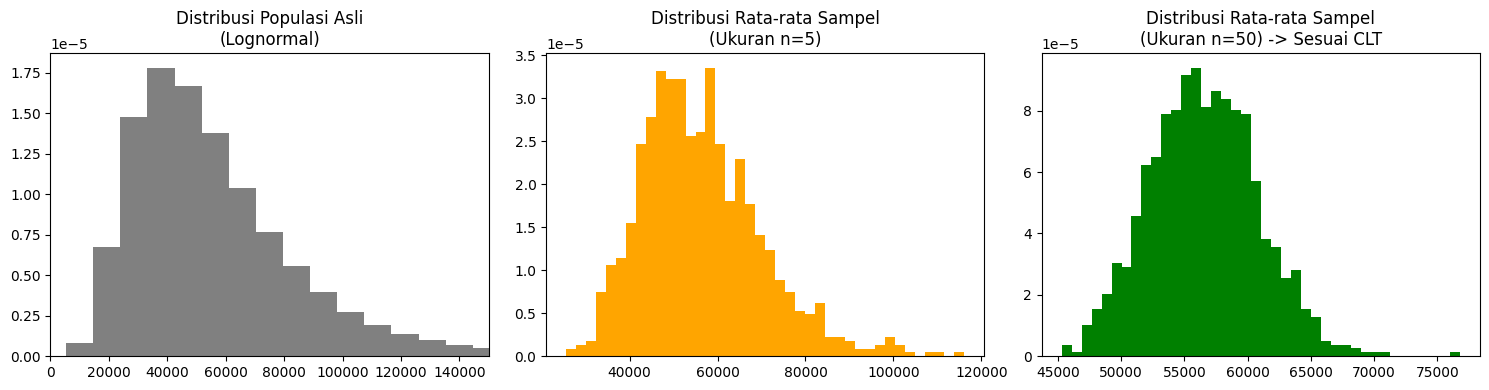

In [3]:
# Simulasi Central Limit Theorem
sample_means_5 = [np.mean(np.random.choice(population, size=5)) for _ in range(1000)]
sample_means_50 = [np.mean(np.random.choice(population, size=50)) for _ in range(1000)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribusi Asli (Sangat miring / tidak normal)
axes[0].hist(population, bins=50, color='gray', density=True)
axes[0].set_title('Distribusi Populasi Asli\n(Lognormal)')
axes[0].set_xlim(0, 150000)

# Distribusi Rata-rata (n=5)
axes[1].hist(sample_means_5, bins=40, color='orange', density=True)
axes[1].set_title('Distribusi Rata-rata Sampel\n(Ukuran n=5)')

# Distribusi Rata-rata (n=50) -> Menjadi Normal!
axes[2].hist(sample_means_50, bins=40, color='green', density=True)
axes[2].set_title('Distribusi Rata-rata Sampel\n(Ukuran n=50) -> Sesuai CLT')

plt.tight_layout()
plt.show()

## 4. The Bootstrap
Bagaimana jika kita hanya punya satu sampel dan tidak tahu bentuk populasinya? Kita gunakan **Bootstrap**.
Bootstrap adalah teknik *resampling* (pengambilan sampel ulang) **dengan pengembalian (with replacement)** dari sampel asli kita. Ini memungkinkan kita untuk memperkirakan *Standard Error* dan membangun *Confidence Interval* (Interval Kepercayaan) tanpa memerlukan rumus matematika yang rumit.

=== Hasil Bootstrap untuk Median ===
Original Median : Rp 49,933
Bootstrap Bias  : Rp 105
Standard Error  : Rp 856


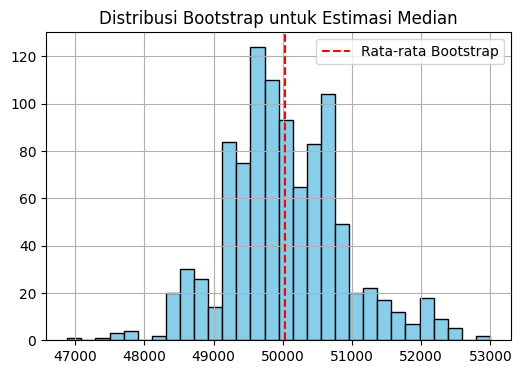

In [4]:
# Kita gunakan 'sample' (ukuran 1000) yang kita buat di awal sebagai data asli kita
results = []
for nrepeat in range(1000):
    # Resample DENGAN pengembalian (replace=True)
    sample_boot = resample(sample, replace=True)
    results.append(np.median(sample_boot)) # Kita coba estimasi rentang Median-nya

results = pd.Series(results)

print("=== Hasil Bootstrap untuk Median ===")
print(f"Original Median : Rp {np.median(sample):,.0f}")
print(f"Bootstrap Bias  : Rp {results.mean() - np.median(sample):,.0f}")
print(f"Standard Error  : Rp {results.std():,.0f}")

plt.figure(figsize=(6,4))
results.hist(bins=30, color='skyblue', edgecolor='black')
plt.title('Distribusi Bootstrap untuk Estimasi Median')
plt.axvline(results.mean(), color='red', linestyle='--', label='Rata-rata Bootstrap')
plt.legend()
plt.show()

## 5. Confidence Intervals (Interval Kepercayaan)
Menyatakan sebuah estimasi sebagai titik tunggal (misal: "rata-rata pendapatan adalah Rp 50.000") seringkali menyesatkan. Lebih baik memberikan *Confidence Interval* (misal: "Kami yakin 95% bahwa rata-rata pendapatan berada di antara Rp 48.000 dan Rp 52.000").

Menggunakan hasil Bootstrap di atas, kita bisa mencari interval 95% dengan mengambil persentil ke-2.5 dan ke-97.5.

In [5]:
conf_int = [results.quantile(0.025), results.quantile(0.975)]
print(f"95% Confidence Interval untuk Median Populasi:")
print(f"[Rp {conf_int[0]:,.0f}  sampai  Rp {conf_int[1]:,.0f}]")

95% Confidence Interval untuk Median Populasi:
[Rp 48,449  sampai  Rp 52,070]


## 6. Normal Distribution dan QQ-Plot
Banyak metode statistik mengasumsikan data terdistribusi normal. Untuk mengecek secara visual apakah sebuah data berdistribusi normal, alat terbaik yang digunakan adalah **QQ-Plot (Quantile-Quantile Plot)**. Jika data jatuh membentuk garis lurus diagonal, maka data tersebut berdistribusi normal.

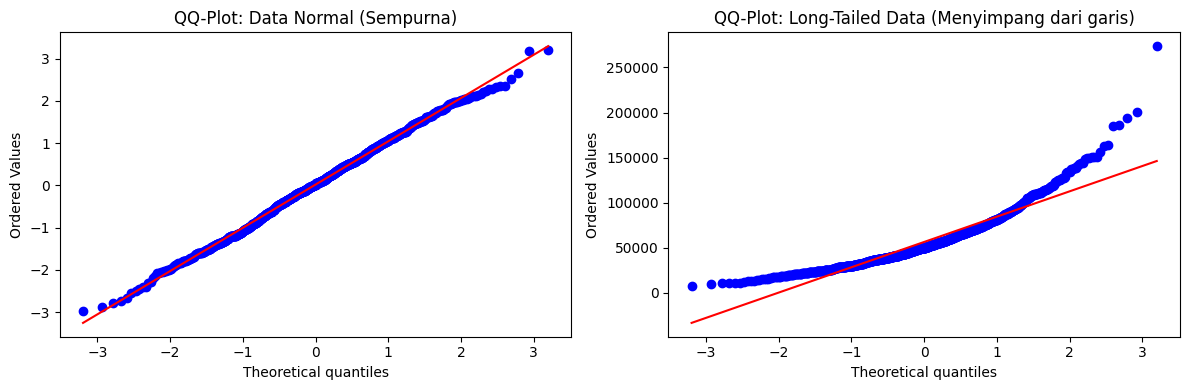

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# QQ-Plot untuk Data Normal
norm_data = np.random.normal(0, 1, 1000)
stats.probplot(norm_data, plot=ax[0])
ax[0].set_title('QQ-Plot: Data Normal (Sempurna)')

# QQ-Plot untuk Data kita (Right-skewed, punya ekor panjang di kanan)
stats.probplot(sample, plot=ax[1])
ax[1].set_title('QQ-Plot: Long-Tailed Data (Menyimpang dari garis)')

plt.tight_layout()
plt.show()

## 7. Distribusi Penting Lainnya
Selain normal, buku ini mengenalkan distribusi probabilitas diskrit (berbasis hitungan):
- **Binomial Distribution:** Distribusi hasil dari sejumlah *trials* (percobaan) yang masing-masing hanya punya 2 hasil (sukses/gagal, ya/tidak). Contoh: peluang mendapat 5 klik dari 100 pengunjung web (jika CTR 2%).
- **Poisson Distribution:** Distribusi probabilitas terjadinya sejumlah kejadian dalam rentang waktu atau ruang tertentu. Contoh: Jumlah pelanggan yang datang ke toko per jam.

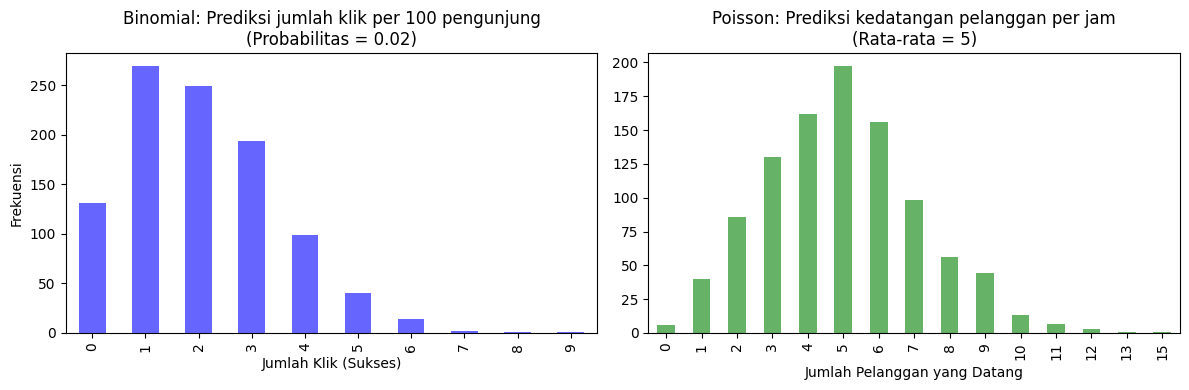

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Simulasi Distribusi Binomial (n=100 pengunjung, p=0.02 rasio konversi/klik)
binom_data = stats.binom.rvs(n=100, p=0.02, size=1000)
pd.Series(binom_data).value_counts().sort_index().plot(kind='bar', ax=ax[0], color='blue', alpha=0.6)
ax[0].set_title('Binomial: Prediksi jumlah klik per 100 pengunjung\n(Probabilitas = 0.02)')
ax[0].set_xlabel('Jumlah Klik (Sukses)')
ax[0].set_ylabel('Frekuensi')

# Simulasi Distribusi Poisson (Rata-rata (lambda) = 5 pelanggan per jam)
poisson_data = stats.poisson.rvs(mu=5, size=1000)
pd.Series(poisson_data).value_counts().sort_index().plot(kind='bar', ax=ax[1], color='green', alpha=0.6)
ax[1].set_title('Poisson: Prediksi kedatangan pelanggan per jam\n(Rata-rata = 5)')
ax[1].set_xlabel('Jumlah Pelanggan yang Datang')

plt.tight_layout()
plt.show()


---
*Catatan Tambahan: Pemahaman mendalam mengenai Bootstrap dan CLT di bab ini adalah pondasi krusial bagi Data Scientist untuk melakukan pengujian A/B (A/B Testing) yang akan dibahas pada bab selanjutnya.*